# Comprensión y EDA - Riesgo Crediticio

**Autor:** Juan Martín Rossi
**Fecha:** 2026-08-26

**Objetivo de este notebook:** explorar en profundidad el dataset de créditos otorgados (`Base_de_datos.csv`, generado por `cargar_datos.ipynb`) para entender su estructura, calidad y contenido antes de modelar. Esta primera parte cubre **exploración inicial y saneamiento de tipos**: caracterización de variables, unificación de nulos, casteo a los tipos correctos, identificación de columnas candidatas a eliminar (sin borrarlas todavía) y documentación de anomalías. El análisis univariable, bivariable y multivariable, y las conclusiones accionables, van en secciones posteriores de este mismo notebook.

## Diccionario de datos

23 columnas, una fila por crédito otorgado. Montos en pesos colombianos (COP). `puntaje_datacredito` es el score del buró de crédito colombiano DataCrédito.

| Columna | Significado de negocio | Tipo esperado |
|---|---|---|
| `tipo_credito` | Código del tipo/producto de crédito otorgado | Categórica nominal |
| `fecha_prestamo` | Fecha y hora en que se otorgó el crédito | Fecha |
| `capital_prestado` | Monto de capital otorgado (COP) | Numérica continua |
| `plazo_meses` | Plazo pactado del crédito, en meses | Numérica discreta |
| `edad_cliente` | Edad del cliente en años | Numérica discreta |
| `tipo_laboral` | Situación laboral del cliente (Empleado / Independiente) | Dicotómica |
| `salario_cliente` | Ingreso mensual declarado del cliente (COP) | Numérica continua |
| `total_otros_prestamos` | Saldo de otras deudas del cliente al momento de la solicitud (COP) | Numérica continua |
| `cuota_pactada` | Valor de la cuota mensual pactada (COP) | Numérica continua |
| `puntaje` | Score interno de originación de la entidad | Numérica continua |
| `puntaje_datacredito` | Score del buró DataCrédito | Numérica discreta |
| `cant_creditosvigentes` | Cantidad de créditos vigentes del cliente en el sistema financiero | Numérica discreta |
| `huella_consulta` | Cantidad de consultas de crédito recientes sobre el cliente | Numérica discreta |
| `saldo_mora` | Saldo en mora del cliente en otros créditos (COP) | Numérica continua |
| `saldo_total` | Saldo total de deuda del cliente en el sistema (COP) | Numérica continua |
| `saldo_principal` | Saldo de capital de la deuda del cliente, sin mora (COP) | Numérica continua |
| `saldo_mora_codeudor` | Saldo en mora del codeudor del crédito (COP) | Numérica continua |
| `creditos_sectorFinanciero` | Cantidad de créditos vigentes en el sector financiero (bancos) | Numérica discreta |
| `creditos_sectorCooperativo` | Cantidad de créditos vigentes en el sector cooperativo | Numérica discreta |
| `creditos_sectorReal` | Cantidad de créditos vigentes en el sector real (comercio/retail) | Numérica discreta |
| `promedio_ingresos_datacredito` | Promedio de ingresos del cliente reportado por DataCrédito (COP) | Numérica continua |
| `tendencia_ingresos` | Tendencia de los ingresos del cliente según DataCrédito | Categórica ordinal |
| **`Pago_atiempo`** | **Variable objetivo: 1 = pagó a tiempo, 0 = no pagó a tiempo** | **Dicotómica (target)** |


## Carga del dataset

Se carga el `.csv` materializado por `cargar_datos.ipynb`, otra vez con `dtype=str`: el saneamiento de tipos es justamente el trabajo de este notebook, así que no tiene sentido dejar que `pandas` infiera tipos por su cuenta antes de decidir nosotros cómo castear cada columna.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 30)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUTA_CSV = RAIZ / "data" / "raw" / "Base_de_datos.csv"

df = pd.read_csv(RUTA_CSV, dtype=str, encoding="utf-8")
df.shape

(10763, 23)

## Descripción general

Antes de mirar columna por columna, un pantallazo del dataset completo: forma, tipos que trae desde el CSV (todos `object`, esperado), memoria que ocupa en memoria (no en disco), cuántas filas son duplicados exactos (indicaría créditos cargados dos veces) y cuántos valores distintos tiene cada columna (una primera pista de cardinalidad).

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (10763, 23)
<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   tipo_credito                   10763 non-null  str  
 1   fecha_prestamo                 10763 non-null  str  
 2   capital_prestado               10763 non-null  str  
 3   plazo_meses                    10763 non-null  str  
 4   edad_cliente                   10763 non-null  str  
 5   tipo_laboral                   10763 non-null  str  
 6   salario_cliente                10763 non-null  str  
 7   total_otros_prestamos          10763 non-null  str  
 8   cuota_pactada                  10763 non-null  str  
 9   puntaje                        10763 non-null  str  
 10  puntaje_datacredito            10757 non-null  str  
 11  cant_creditosvigentes          10763 non-null  str  
 12  huella_consulta                10763 non-null  str  
 13  saldo_mo

In [3]:
memoria_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memoria usada: {memoria_mb:.2f} MB")

filas_duplicadas = df.duplicated().sum()
print(f"Filas duplicadas exactas: {filas_duplicadas}")

Memoria usada: 3.03 MB
Filas duplicadas exactas: 0


In [4]:
valores_unicos = df.nunique(dropna=True).sort_values(ascending=False)
valores_unicos

fecha_prestamo                   10758
cuota_pactada                     9836
saldo_total                       8892
saldo_principal                   8692
capital_prestado                  7306
promedio_ingresos_datacredito     5309
total_otros_prestamos             1538
salario_cliente                   1385
puntaje_datacredito                472
puntaje                            248
saldo_mora                          57
edad_cliente                        54
tendencia_ingresos                  46
cant_creditosvigentes               39
creditos_sectorFinanciero           33
huella_consulta                     28
creditos_sectorReal                 24
plazo_meses                         18
creditos_sectorCooperativo          11
tipo_credito                         6
saldo_mora_codeudor                  5
tipo_laboral                         2
Pago_atiempo                         2
dtype: int64

## Caracterización de variables

Se arma una tabla resumen con `pandas` (cardinalidad, `% de nulos` y ejemplos calculados, no tipeados a mano) y se le suma el **tipo semántico**, que es la única columna que requiere criterio de negocio y no se puede inferir automáticamente del dtype. Dos casos a tener en cuenta explícitamente: `tipo_credito` trae códigos numéricos pero es **categórica nominal** (el número es una etiqueta, no una cantidad — sumar o promediar códigos de tipo de crédito no tiene sentido), y `tendencia_ingresos` es **categórica ordinal** (`Decreciente` < `Estable` < `Creciente` tiene un orden natural).

In [5]:
TIPO_SEMANTICO = {
    "tipo_credito": "categórica nominal",
    "fecha_prestamo": "fecha",
    "capital_prestado": "numérica continua",
    "plazo_meses": "numérica discreta",
    "edad_cliente": "numérica discreta",
    "tipo_laboral": "dicotómica",
    "salario_cliente": "numérica continua",
    "total_otros_prestamos": "numérica continua",
    "cuota_pactada": "numérica continua",
    "puntaje": "numérica continua",
    "puntaje_datacredito": "numérica discreta",
    "cant_creditosvigentes": "numérica discreta",
    "huella_consulta": "numérica discreta",
    "saldo_mora": "numérica continua",
    "saldo_total": "numérica continua",
    "saldo_principal": "numérica continua",
    "saldo_mora_codeudor": "numérica continua",
    "creditos_sectorFinanciero": "numérica discreta",
    "creditos_sectorCooperativo": "numérica discreta",
    "creditos_sectorReal": "numérica discreta",
    "promedio_ingresos_datacredito": "numérica continua",
    "tendencia_ingresos": "categórica ordinal",
    "Pago_atiempo": "dicotómica (variable objetivo)",
}

caracterizacion = pd.DataFrame({
    "columna": df.columns,
    "tipo_detectado": [str(df[c].dtype) for c in df.columns],
    "tipo_semantico": [TIPO_SEMANTICO[c] for c in df.columns],
    "cardinalidad": [df[c].nunique(dropna=True) for c in df.columns],
    "pct_nulos": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
    "ejemplos": [list(df[c].dropna().unique()[:3]) for c in df.columns],
})
caracterizacion

,columna,tipo_detectado,tipo_semantico,cardinalidad,pct_nulos,ejemplos
0,tipo_credito,str,categórica nominal,6,0.00,"[7, 4, 9]"
1,fecha_prestamo,str,fecha,10758,0.00,"[2024-12-21 11:31:35, 2025-04-22 09:47:35, 202..."
2,capital_prestado,str,numérica continua,7306,0.00,"[3692160, 840000, 5974028.399999999]"
3,plazo_meses,str,numérica discreta,18,0.00,"[10, 6, 11]"
4,edad_cliente,str,numérica discreta,54,0.00,"[42, 60, 36]"
5,tipo_laboral,str,dicotómica,2,0.00,"[Independiente, Empleado]"
6,salario_cliente,str,numérica continua,1385,0.00,"[8000000, 3000000, 4036000]"
7,total_otros_prestamos,str,numérica continua,1538,0.00,"[2500000, 2000000, 829000]"
8,cuota_pactada,str,numérica continua,9836,0.00,"[341296, 124876, 529554]"
9,puntaje,str,numérica continua,248,0.00,"[88.768094, 95.227787, 47.613894]"


## Unificación de nulos

Pandas ya interpreta como `NaN` algunas formas comunes de faltante al leer el CSV (celda vacía, `NA`, `N/A`, `null`, `None`, entre otras de su lista por defecto). Pero eso no cubre todo: hay que buscar explícitamente espacios en blanco, guiones, signos de pregunta, y **ceros que en realidad significan "sin dato"** — este último caso no se puede aplicar a ciegas a todas las columnas (un `0` en `creditos_sectorReal` es un dato real: "no tiene créditos en ese sector"), así que se justifica columna por columna.

Se registra el conteo de nulos **antes** de tocar nada, para poder comparar contra el de después.

In [6]:
nulos_antes = df.isna().sum()
nulos_antes.sort_values(ascending=False)

tendencia_ingresos               2932
promedio_ingresos_datacredito    2930
saldo_mora_codeudor               590
saldo_principal                   405
saldo_total                       156
saldo_mora                        156
puntaje_datacredito                 6
tipo_credito                        0
huella_consulta                     0
creditos_sectorReal                 0
creditos_sectorCooperativo          0
creditos_sectorFinanciero           0
cant_creditosvigentes               0
fecha_prestamo                      0
puntaje                             0
cuota_pactada                       0
total_otros_prestamos               0
salario_cliente                     0
tipo_laboral                        0
edad_cliente                        0
plazo_meses                         0
capital_prestado                    0
Pago_atiempo                        0
dtype: int64

Formas de faltante a unificar a `np.nan`, además de lo que pandas ya detectó: celda vacía, string vacío, solo espacios, `"NA"`, `"N/A"`, `"null"`, `"None"`, `"-"`, `"?"`.

In [7]:
SENTINELS_TEXTO = {"", "NA", "N/A", "null", "None", "-", "?"}


def es_sentinel(valor):
    if pd.isna(valor):
        return True
    return str(valor).strip() in SENTINELS_TEXTO


sentinels_encontrados = 0
for columna in df.columns:
    mascara = df[columna].apply(es_sentinel) & df[columna].notna()
    if mascara.any():
        print(f"{columna}: {mascara.sum()} sentinels de texto encontrados")
        sentinels_encontrados += mascara.sum()
    df.loc[df[columna].apply(es_sentinel), columna] = np.nan

if sentinels_encontrados == 0:
    print("No se encontraron sentinels de texto (NA/N/A/null/None/-/?/espacios) además de la celda vacía: "
          "en este dataset la única forma de faltante 'de texto' es la celda vacía, que pandas ya había detectado.")

No se encontraron sentinels de texto (NA/N/A/null/None/-/?/espacios) además de la celda vacía: en este dataset la única forma de faltante 'de texto' es la celda vacía, que pandas ya había detectado.


**Caso de cero como "sin dato": `puntaje_datacredito`.** Es un score de buró; su rango observado (excluyendo el 0) va de valores negativos puntuales hasta 999, con la mayoría concentrada entre 700 y 900. Un score exactamente en `0` no es un valor bajo del score, es un valor que no aparece en ningún otro lugar de la distribución natural: es el patrón típico de un sentinel de "no se pudo calcular / sin información en el buró", no una puntuación real. Se unifica a `NaN`, documentando cuántas filas afecta.

**Caso de valores fuera de dominio: `tendencia_ingresos`.** Es categórica con dominio válido `{Creciente, Estable, Decreciente}`. Al revisar sus valores únicos aparecen además números sueltos (ingresos, parece un problema de carga de datos ajeno a esta columna) que no son ninguna de las tres categorías válidas. No son un faltante "de texto" como los anteriores, pero tampoco son información utilizable: se tratan como `NaN` porque no representan ninguna categoría real del dominio de negocio.

In [8]:
ceros_puntaje_dc = pd.to_numeric(df["puntaje_datacredito"], errors="coerce") == 0
print(f"puntaje_datacredito: {ceros_puntaje_dc.sum()} valores en 0 unificados a NaN "
      f"({100 * ceros_puntaje_dc.sum() / len(df):.2f}% del total)")
df.loc[ceros_puntaje_dc, "puntaje_datacredito"] = np.nan

DOMINIO_TENDENCIA = {"Creciente", "Estable", "Decreciente"}
fuera_de_dominio = df["tendencia_ingresos"].notna() & ~df["tendencia_ingresos"].isin(DOMINIO_TENDENCIA)
print(f"tendencia_ingresos: {fuera_de_dominio.sum()} valores fuera de dominio unificados a NaN "
      f"({100 * fuera_de_dominio.sum() / len(df):.2f}% del total)")
df.loc[fuera_de_dominio, "tendencia_ingresos"] = np.nan

puntaje_datacredito: 145 valores en 0 unificados a NaN (1.35% del total)
tendencia_ingresos: 58 valores fuera de dominio unificados a NaN (0.54% del total)


Con todo unificado, se compara el conteo de nulos antes y después, en absoluto y en porcentaje, ordenado de mayor a menor nulidad final.

In [9]:
nulos_despues = df.isna().sum()

comparacion_nulos = pd.DataFrame({
    "nulos_antes": nulos_antes,
    "pct_antes": (nulos_antes / len(df) * 100).round(2),
    "nulos_despues": nulos_despues,
    "pct_despues": (nulos_despues / len(df) * 100).round(2),
}).sort_values("pct_despues", ascending=False)
comparacion_nulos

,nulos_antes,pct_antes,nulos_despues,pct_despues
tendencia_ingresos,2932,27.24,2990,27.78
promedio_ingresos_datacredito,2930,27.22,2930,27.22
saldo_mora_codeudor,590,5.48,590,5.48
saldo_principal,405,3.76,405,3.76
saldo_total,156,1.45,156,1.45
saldo_mora,156,1.45,156,1.45
puntaje_datacredito,6,0.06,151,1.40
tipo_credito,0,0.00,0,0.00
huella_consulta,0,0.00,0,0.00
creditos_sectorReal,0,0.00,0,0.00


## Casteo de tipos

Empezamos por `fecha_prestamo`. El Excel original la guarda como fecha nativa con formato de visualización `m/d/yy h:mm` (mes/día/año hora:minuto) — pero como `cargar_datos.ipynb` la leyó con `openpyxl`, ese valor nativo ya quedó resuelto a un `datetime` de Python antes de escribirse en el CSV, y por eso en el `.csv` aparece en texto ISO (`AAAA-MM-DD HH:MM:SS`), no en `m/d/a`. Por eso `pd.to_datetime` la parsea directo, sin pasarle un `format` de mes/día/año: si se le pasara ese formato explícito, fallaría, porque el texto que realmente hay en el CSV ya no está en ese formato. De todas formas se verifica que no haya quedado ningún valor sin poder convertir.

In [10]:
nulos_fecha_antes = df["fecha_prestamo"].isna().sum()
df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"], errors="coerce")
fechas_no_convertidas = df["fecha_prestamo"].isna().sum() - nulos_fecha_antes
print(f"fecha_prestamo: {fechas_no_convertidas} valores no se pudieron convertir a datetime")
df["fecha_prestamo"].describe()

fecha_prestamo: 0 valores no se pudieron convertir a datetime


count                         10763
mean     2025-04-16 23:06:02.111121
min             2024-11-26 09:17:04
25%      2025-01-20 17:33:07.500000
50%             2025-03-27 16:23:12
75%             2025-06-16 13:27:58
max             2026-04-26 18:43:52
Name: fecha_prestamo, dtype: object

Ahora los montos, scores y conteos numéricos, con `pd.to_numeric(errors="coerce")`. Se reporta, por columna, cuántos valores **no nulos** no se pudieron convertir (para no confundir "ya era nulo" con "falló la conversión").

In [11]:
COLUMNAS_NUMERICAS = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "saldo_mora", "saldo_total",
    "saldo_principal", "saldo_mora_codeudor", "creditos_sectorFinanciero",
    "creditos_sectorCooperativo", "creditos_sectorReal", "promedio_ingresos_datacredito",
]

reporte_casteo_numerico = []
for columna in COLUMNAS_NUMERICAS:
    nulos_antes_cast = df[columna].isna().sum()
    df[columna] = pd.to_numeric(df[columna], errors="coerce")
    nulos_despues_cast = df[columna].isna().sum()
    reporte_casteo_numerico.append({
        "columna": columna,
        "no_convertidos": int(nulos_despues_cast - nulos_antes_cast),
    })

pd.DataFrame(reporte_casteo_numerico)

,columna,no_convertidos
0,capital_prestado,0
1,plazo_meses,0
2,edad_cliente,0
3,salario_cliente,0
4,total_otros_prestamos,0
5,cuota_pactada,0
6,puntaje,0
7,puntaje_datacredito,0
8,cant_creditosvigentes,0
9,huella_consulta,0


Las categóricas (`tipo_credito`, `tipo_laboral`, `tendencia_ingresos`) a `category`. `tendencia_ingresos` además se deja **ordenada** (`Decreciente < Estable < Creciente`), reflejando que es ordinal.

In [12]:
COLUMNAS_CATEGORICAS = ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]
for columna in COLUMNAS_CATEGORICAS:
    df[columna] = df[columna].astype("category")

df["tendencia_ingresos"] = df["tendencia_ingresos"].cat.reorder_categories(
    ["Decreciente", "Estable", "Creciente"], ordered=True
)

df[COLUMNAS_CATEGORICAS].dtypes

tipo_credito          category
tipo_laboral          category
tendencia_ingresos    category
dtype: object

Por último, `Pago_atiempo` a entero: ya viene sin nulos y con solo dos valores (`"0"`/`"1"`), así que el casteo es directo.

In [13]:
df["Pago_atiempo"] = df["Pago_atiempo"].astype(int)
df["Pago_atiempo"].dtype, df["Pago_atiempo"].unique()

(dtype('int64'), array([1, 0]))

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  category      
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  category      
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10612 non-null  float64       
 11  cant_creditosvigentes     

## Candidatas a eliminar (sin borrar todavía)

Tres criterios, calculados sobre el dataset ya casteado:

1. **Constantes o casi constantes**: columnas donde un mismo valor concentra ≥95% de los casos no nulos. Se excluye `Pago_atiempo` de este chequeo a propósito: es la variable objetivo, nunca es candidata a eliminar por más desbalanceada que esté su distribución de clases — ese desbalance se analiza más adelante, en el análisis univariable, como un tema de modelado, no de descarte de columnas.
2. **Más del 90% de nulos**: usando el conteo de nulos ya unificado.
3. **Duplicadas entre sí**: pares de columnas numéricas que coinciden en más del 95% de las filas donde ambas tienen dato.

No se borra nada en esta celda ni en las siguientes: se arma la tabla de candidatas con su justificación numérica y se espera confirmación antes de tocar el dataset.

In [15]:
casi_constantes = []
for columna in df.columns:
    if columna == "Pago_atiempo":
        continue
    frecuencias = df[columna].value_counts(normalize=True, dropna=True)
    if len(frecuencias) > 0 and frecuencias.iloc[0] >= 0.95:
        casi_constantes.append({
            "columna": columna,
            "valor_dominante": frecuencias.index[0],
            "pct_valor_dominante": round(frecuencias.iloc[0] * 100, 2),
        })

df_casi_constantes = pd.DataFrame(casi_constantes)
df_casi_constantes

,columna,valor_dominante,pct_valor_dominante
0,saldo_mora,0.0,99.48
1,saldo_mora_codeudor,0.0,99.97


In [16]:
# Caso puntual pedido: saldo_mora, ¿realmente vale 0 en todas las filas?
pct_cero_saldo_mora = (df["saldo_mora"] == 0).mean() * 100
print(f"saldo_mora == 0 en el {pct_cero_saldo_mora:.2f}% de las filas "
      f"(no es el 100%, pero es casi constante: el resto son saldos en mora reales, "
      f"con valores como los que se ven en el head de cargar_datos.ipynb).")

saldo_mora == 0 en el 98.04% de las filas (no es el 100%, pero es casi constante: el resto son saldos en mora reales, con valores como los que se ven en el head de cargar_datos.ipynb).


In [17]:
pct_nulos_final = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
alta_nulidad = pct_nulos_final[pct_nulos_final > 90]
if alta_nulidad.empty:
    print("Ninguna columna supera el 90% de nulos.")
alta_nulidad

Ninguna columna supera el 90% de nulos.


Series([], dtype: float64)

In [18]:
columnas_numericas_actuales = df.select_dtypes(include="number").columns
pares_duplicados = []
for i in range(len(columnas_numericas_actuales)):
    for j in range(i + 1, len(columnas_numericas_actuales)):
        col_a, col_b = columnas_numericas_actuales[i], columnas_numericas_actuales[j]
        mascara = df[col_a].notna() & df[col_b].notna()
        if mascara.sum() > 0:
            coincidencia = (df.loc[mascara, col_a] == df.loc[mascara, col_b]).mean()
            if coincidencia > 0.95:
                pares_duplicados.append({
                    "columna_a": col_a,
                    "columna_b": col_b,
                    "pct_coincidencia": round(coincidencia * 100, 2),
                    "filas_comparadas": int(mascara.sum()),
                })

df_duplicadas = pd.DataFrame(pares_duplicados)
df_duplicadas

,columna_a,columna_b,pct_coincidencia,filas_comparadas
0,saldo_mora,saldo_mora_codeudor,99.69,10173


In [19]:
filas_candidatas = []

for _, fila in df_casi_constantes.iterrows():
    filas_candidatas.append({
        "columna": fila["columna"],
        "criterio": "casi constante",
        "justificacion_numerica": f"{fila['pct_valor_dominante']}% de las filas valen "
                                   f"'{fila['valor_dominante']}'",
    })

for _, fila in df_duplicadas.iterrows():
    filas_candidatas.append({
        "columna": f"{fila['columna_a']} / {fila['columna_b']}",
        "criterio": "duplicada entre sí",
        "justificacion_numerica": f"{fila['pct_coincidencia']}% de coincidencia exacta "
                                   f"en {fila['filas_comparadas']} filas comparables",
    })

for columna, pct in alta_nulidad.items():
    filas_candidatas.append({
        "columna": columna,
        "criterio": "más del 90% de nulos",
        "justificacion_numerica": f"{pct:.2f}% de nulos",
    })

tabla_candidatas = pd.DataFrame(filas_candidatas)
tabla_candidatas

,columna,criterio,justificacion_numerica
0,saldo_mora,casi constante,99.48% de las filas valen '0.0'
1,saldo_mora_codeudor,casi constante,99.97% de las filas valen '0.0'
2,saldo_mora / saldo_mora_codeudor,duplicada entre sí,99.69% de coincidencia exacta en 10173 filas c...


**Sin borrar nada todavía.** Queda pendiente tu confirmación sobre esta lista antes de eliminar cualquier columna del dataset.

## Anomalías a investigar: `puntaje`

Dos cosas raras en `puntaje` (el score interno de originación, no el de DataCrédito): un valor que se repite muchísimo cerca de `95.2278`, y valores negativos, lo cual no tiene sentido para un score.

In [20]:
valor_repetido = df["puntaje"].mode(dropna=True).iloc[0]
mascara_repetido = np.isclose(df["puntaje"], valor_repetido)
pct_repetido = mascara_repetido.mean() * 100
print(f"Valor repetido: {valor_repetido} -> aparece en {mascara_repetido.sum()} filas "
      f"({pct_repetido:.2f}% del total)")

mascara_negativos = df["puntaje"] < 0
pct_negativos = mascara_negativos.mean() * 100
print(f"Valores negativos: {mascara_negativos.sum()} filas ({pct_negativos:.2f}% del total), "
      f"mínimo = {df['puntaje'].min():.4f}")

Valor repetido: 95.227787 -> aparece en 9407 filas (87.40% del total)
Valores negativos: 135 filas (1.25% del total), mínimo = -38.0100


**Hipótesis sobre el valor repetido (~87% de las filas en `95.227787`):** un score que se repite de forma tan masiva y con tantos decimales idénticos no es un score "real" calculado caso por caso — tiene toda la pinta de ser un **valor de relleno (fallback) que el motor de scoring devuelve cuando no puede calcular un score real** para ese crédito (por ejemplo, por falta de variables de entrada, un error del modelo, o un límite superior de saturación del modelo que a la mayoría de los casos les da ese mismo techo). Que sea justo el valor más alto del resto de la distribución razonable refuerza la idea de un techo/sentinel, no de una coincidencia real de negocio.

**Hipótesis sobre los negativos (~1.25% de las filas):** un score de riesgo no debería ser negativo bajo ninguna definición de negocio razonable. Es compatible con un error de transformación (por ejemplo, una resta o una normalización que no se truncó en 0) aplicado a un subconjunto de casos, más que con una categoría de riesgo real "peor que el mínimo".

## Cierre de esta etapa

Hallazgos de la exploración inicial y el saneamiento de tipos:

- El dataset tiene 10.763 créditos y 23 columnas, sin filas duplicadas exactas.
- La única forma "de texto" de faltante que existe realmente en este dataset es la celda vacía; no aparecen literalmente `NA`, `N/A`, `null`, `None`, `-` ni `?` como strings. Sí aparecieron dos problemas de calidad que no son faltantes de texto pero equivalen a "sin dato": `puntaje_datacredito` en `0` (score de buró implausible) y valores numéricos sueltos fuera de dominio en `tendencia_ingresos`.
- Después de unificar nulos, las columnas con más faltantes siguen siendo `tendencia_ingresos` y `promedio_ingresos_datacredito`, ambas alrededor del 27% — ninguna columna supera el 90% de nulos.
- Se castearon los tipos: `fecha_prestamo` a `datetime`, las columnas numéricas con `pd.to_numeric(errors="coerce")`, `tipo_credito`/`tipo_laboral`/`tendencia_ingresos` a `category` (esta última, ordenada), y `Pago_atiempo` a `int`.
- Candidatas a eliminar detectadas (pendientes de confirmación): `saldo_mora` y `saldo_mora_codeudor` son casi constantes en 0, y además prácticamente duplicadas entre sí — misma información repetida en dos columnas.
- `puntaje` tiene un valor repetido en ~87% de las filas (hipótesis: sentinel/techo del motor de scoring) y ~1.25% de valores negativos (hipótesis: error de transformación), ninguno de los dos parece un score real calculado caso por caso.

Con esto termina la parte de exploración inicial y saneamiento de tipos. El análisis univariable queda para la próxima sección de este mismo notebook.

# Análisis univariable

Con los tipos ya saneados, se describe cada variable por separado: `describe()` general, y después, variable por variable, forma de la distribución, outliers y frecuencias. El objetivo es entender cada columna en aislamiento antes de cruzarla con otras.

## `describe()` general

Ahora que las columnas tienen el tipo correcto, `describe()` da estadísticos reales (antes, con todo en texto, no tenía sentido pedirlo).

In [21]:
VARIABLES_NUMERICAS = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "saldo_mora", "saldo_total",
    "saldo_principal", "saldo_mora_codeudor", "creditos_sectorFinanciero",
    "creditos_sectorCooperativo", "creditos_sectorReal", "promedio_ingresos_datacredito",
]
VARIABLES_CATEGORICAS = ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]

df[VARIABLES_NUMERICAS].describe()

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito
count,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10612.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03
mean,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,791.459386,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06
std,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,52.011420,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06
min,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,758.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05
50%,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,792.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06
75%,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,826.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06
max,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07


In [22]:
df[VARIABLES_CATEGORICAS].describe()

,tipo_credito,tipo_laboral,tendencia_ingresos
count,10763,10763,7773
unique,6,2,3
top,4,Empleado,Creciente
freq,7747,6754,5294


## Variables numéricas: distribución y forma

Para cada variable numérica: histograma con KDE + boxplot en una misma grilla, y un renglón de estadísticos (incluyendo skewness y kurtosis). La clasificación del tipo de distribución **no es a ojo**: sale de una función que aplica umbrales fijos sobre skewness y kurtosis (asimetría y curtosis excedente de Fisher, donde 0 = normal), y ese mismo criterio se imprime como justificación arriba de cada gráfico.

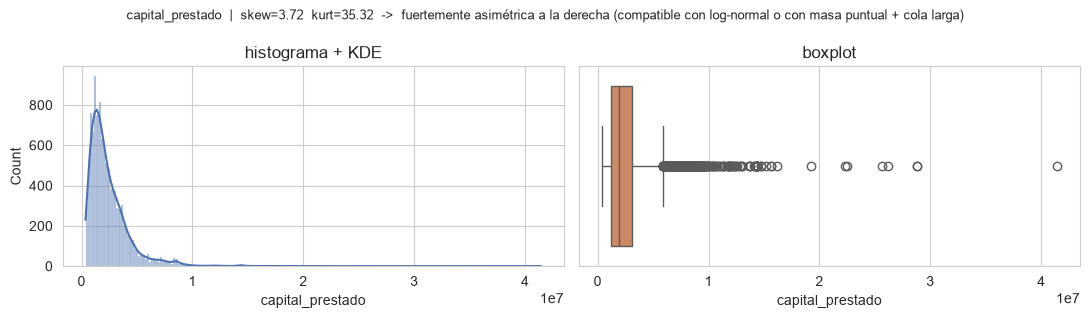

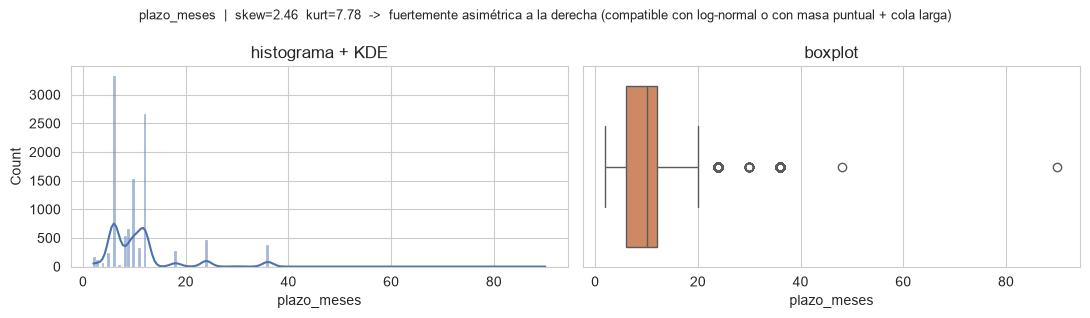

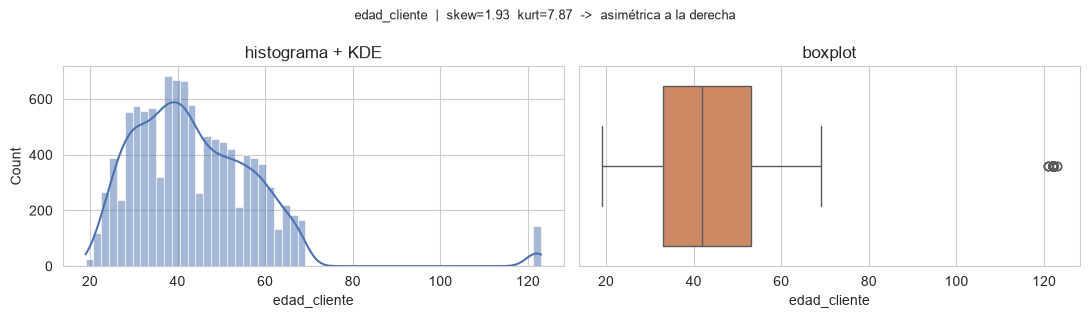

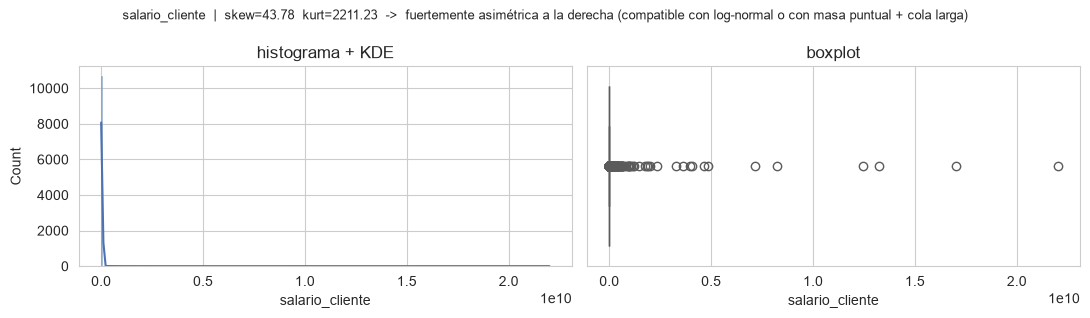

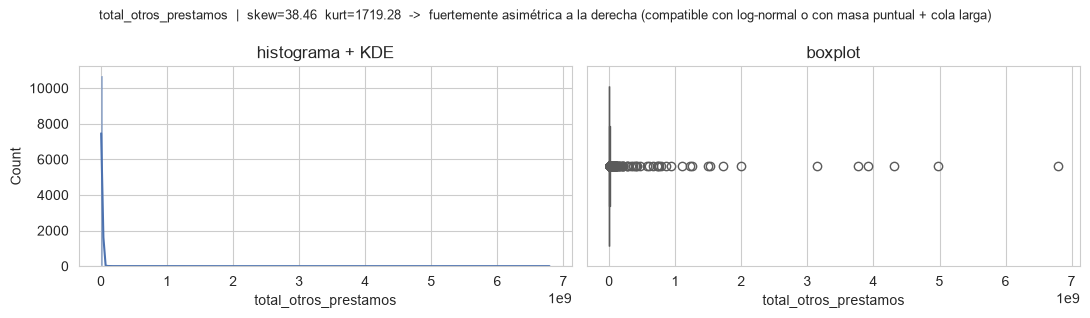

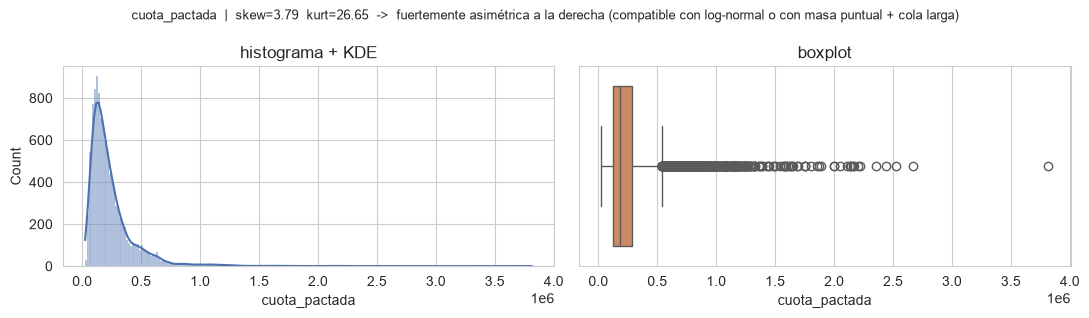

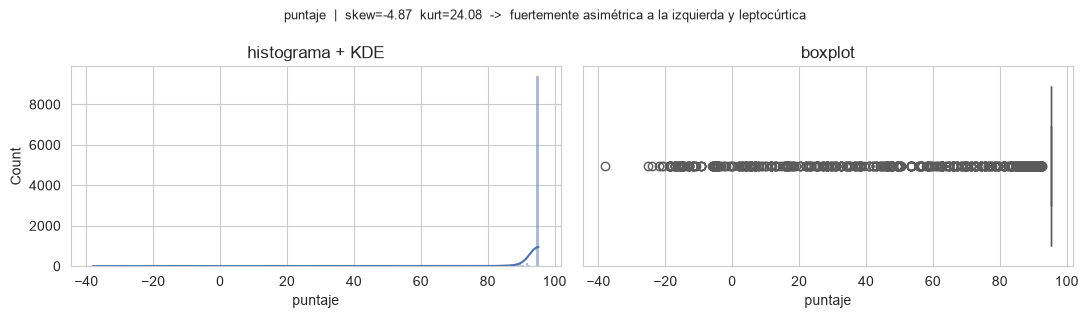

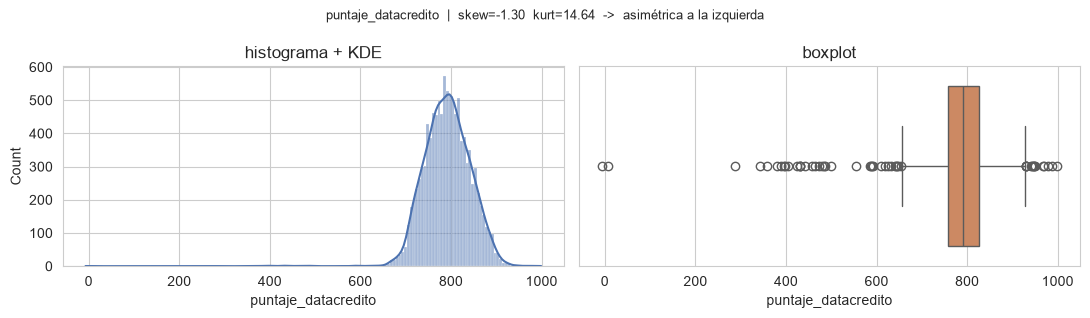

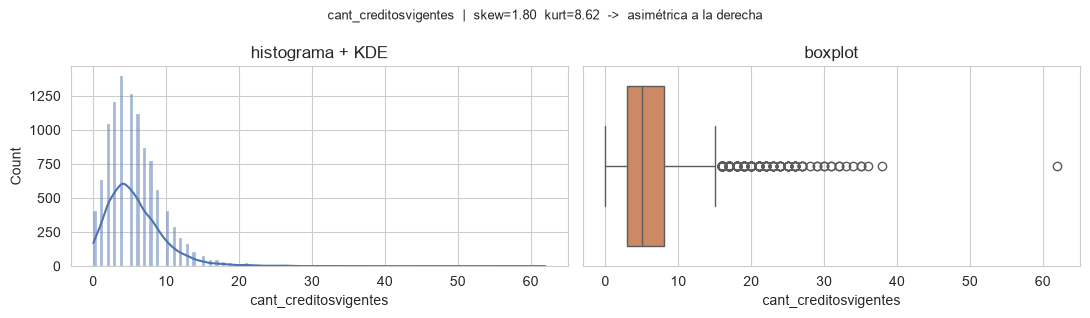

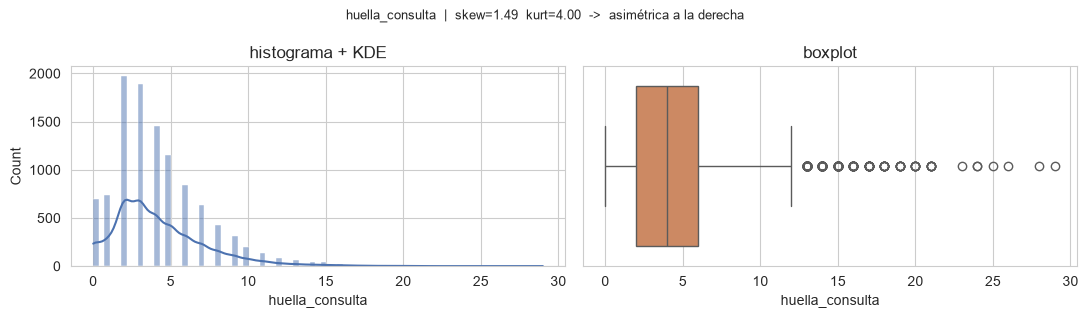

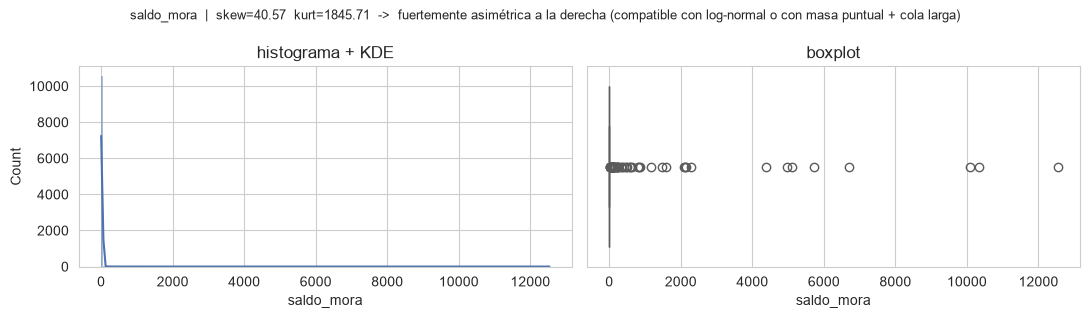

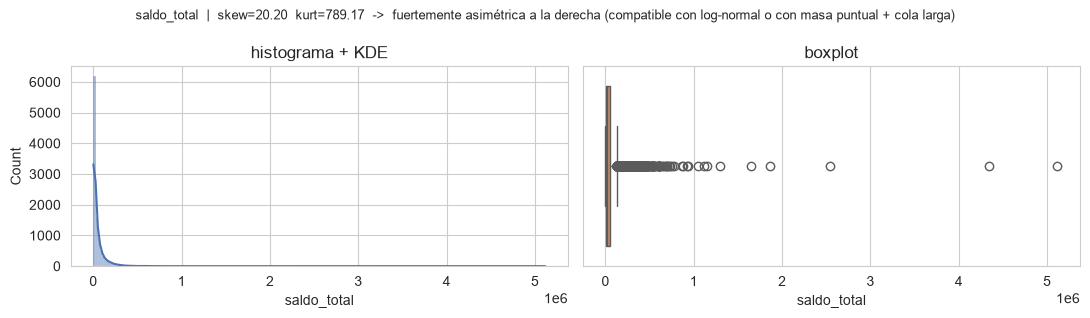

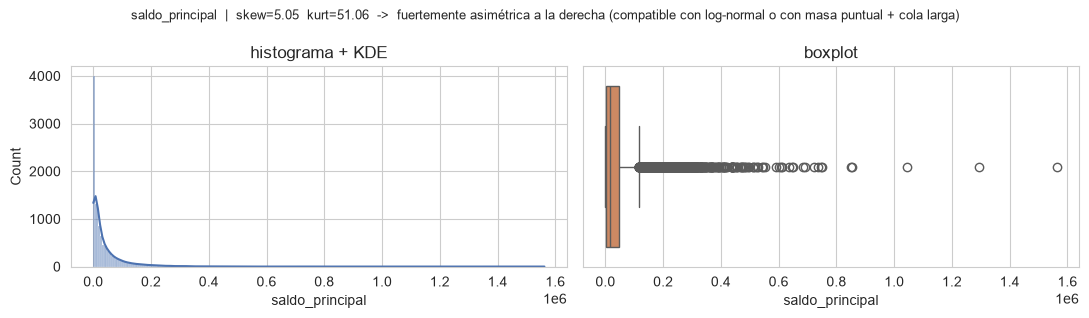

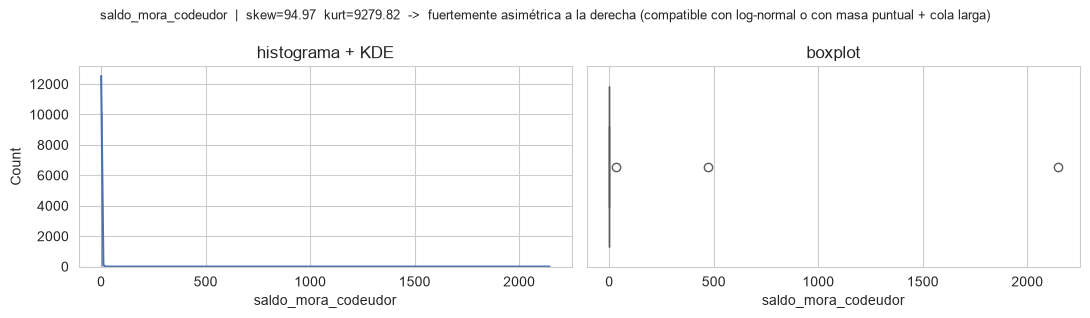

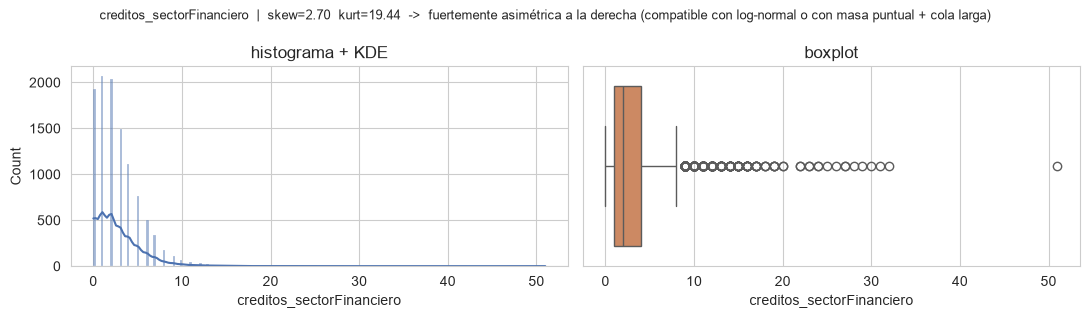

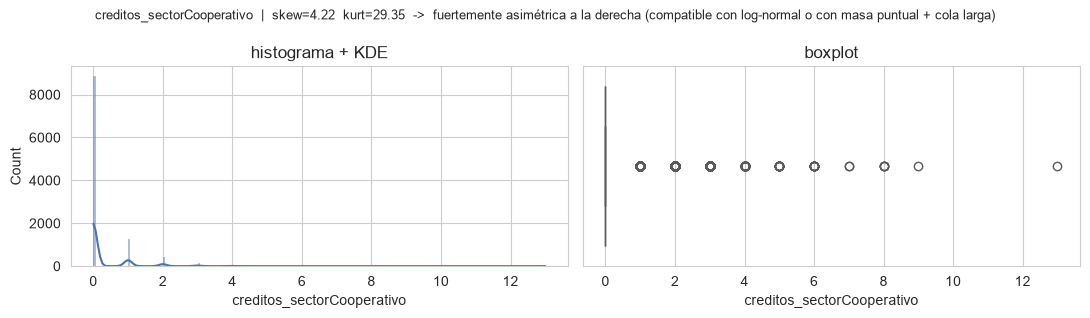

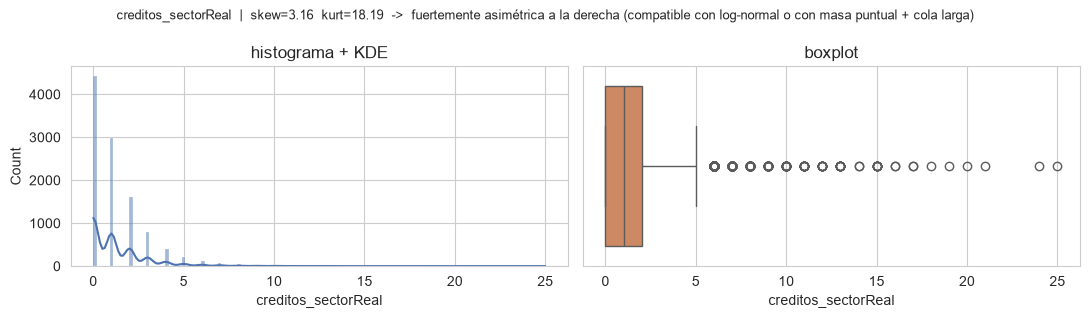

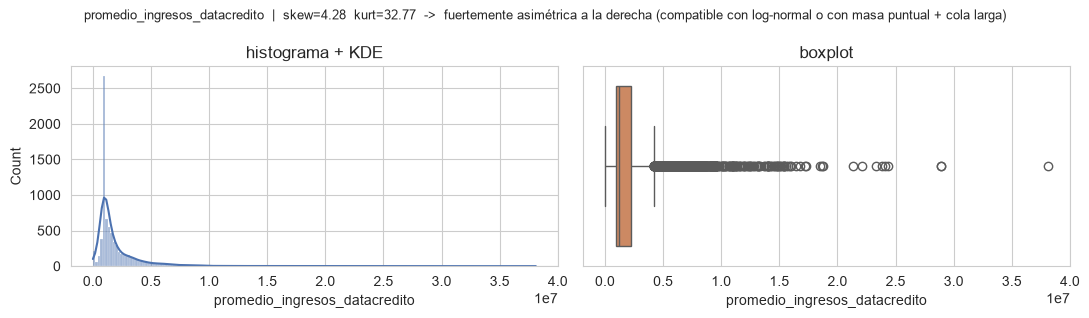

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


def calcular_estadisticas(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    return {
        "media": serie.mean(),
        "mediana": serie.median(),
        "moda": serie.mode().iloc[0] if not serie.mode().empty else np.nan,
        "minimo": serie.min(),
        "maximo": serie.max(),
        "rango": serie.max() - serie.min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "varianza": serie.var(),
        "desvio_std": serie.std(),
        "coef_variacion": (serie.std() / serie.mean()) if serie.mean() != 0 else np.nan,
        "skewness": serie.skew(),
        "kurtosis": serie.kurtosis(),
    }


def clasificar_distribucion(skew, kurt):
    if abs(skew) < 0.5 and abs(kurt) < 0.5:
        return "aproximadamente gaussiana"
    if skew >= 2 and kurt >= 5:
        return "fuertemente asimétrica a la derecha (compatible con log-normal o con masa puntual + cola larga)"
    if skew >= 0.5:
        return "asimétrica a la derecha"
    if skew <= -2 and kurt >= 5:
        return "fuertemente asimétrica a la izquierda y leptocúrtica"
    if skew <= -0.5:
        return "asimétrica a la izquierda"
    if kurt <= -1:
        return "platicúrtica, compatible con una distribución uniforme"
    return "aproximadamente simétrica, sin sesgo marcado"


resumen_numericas = []
for columna in VARIABLES_NUMERICAS:
    serie = df[columna].dropna()
    estadisticas = calcular_estadisticas(serie)
    estadisticas["columna"] = columna
    estadisticas["tipo_distribucion"] = clasificar_distribucion(
        estadisticas["skewness"], estadisticas["kurtosis"]
    )
    resumen_numericas.append(estadisticas)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
    sns.histplot(serie, kde=True, ax=axes[0], color="#4C72B0")
    axes[0].set_title("histograma + KDE")
    sns.boxplot(x=serie, ax=axes[1], color="#DD8452")
    axes[1].set_title("boxplot")
    fig.suptitle(
        f"{columna}  |  skew={estadisticas['skewness']:.2f}  kurt={estadisticas['kurtosis']:.2f}"
        f"  ->  {estadisticas['tipo_distribucion']}",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

Todos los estadísticos y la clasificación, en una sola tabla para poder comparar variables entre sí.

In [24]:
ORDEN_COLUMNAS = ["media", "mediana", "moda", "minimo", "maximo", "rango", "Q1", "Q3", "IQR",
                   "varianza", "desvio_std", "coef_variacion", "skewness", "kurtosis", "tipo_distribucion"]

tabla_resumen_numericas = pd.DataFrame(resumen_numericas).set_index("columna")[ORDEN_COLUMNAS]
tabla_resumen_numericas.iloc[:, :-1] = tabla_resumen_numericas.iloc[:, :-1].astype(float).round(2)
tabla_resumen_numericas

,media,mediana,moda,minimo,maximo,rango,Q1,Q3,IQR,varianza,desvio_std,coef_variacion,skewness,kurtosis,tipo_distribucion
columna,,,,,,,,,,,,,,,
capital_prestado,2434315.00,1921920.00,1200000.00,360000.00,4.144415e+07,4.108415e+07,1224831.00,3084840.00,1860009.00,3.646735e+12,1.909643e+06,0.78,3.72,35.32,fuertemente asimétrica a la derecha (compatibl...
plazo_meses,10.58,10.00,6.00,2.00,9.000000e+01,8.800000e+01,6.00,12.00,6.00,4.398000e+01,6.630000e+00,0.63,2.46,7.78,fuertemente asimétrica a la derecha (compatibl...
edad_cliente,43.95,42.00,40.00,19.00,1.230000e+02,1.040000e+02,33.00,53.00,20.00,2.268300e+02,1.506000e+01,0.34,1.93,7.87,asimétrica a la derecha
salario_cliente,17216431.46,3000000.00,3000000.00,0.00,2.200000e+10,2.200000e+10,2000000.00,4875808.00,2875808.00,1.263637e+17,3.554767e+08,20.65,43.78,2211.23,fuertemente asimétrica a la derecha (compatibl...
total_otros_prestamos,6238869.65,1000000.00,2000000.00,0.00,6.787675e+09,6.787675e+09,500000.00,2000000.00,1500000.00,1.402290e+16,1.184183e+08,18.98,38.46,1719.28,fuertemente asimétrica a la derecha (compatibl...
cuota_pactada,243617.41,182863.00,205990.00,23944.00,3.816752e+06,3.792808e+06,121041.50,287833.50,166792.00,4.430760e+10,2.104937e+05,0.86,3.79,26.65,fuertemente asimétrica a la derecha (compatibl...
puntaje,91.17,95.23,95.23,-38.01,9.523000e+01,1.332400e+02,95.23,95.23,0.00,2.711100e+02,1.647000e+01,0.18,-4.87,24.08,fuertemente asimétrica a la izquierda y leptoc...
puntaje_datacredito,791.46,792.00,783.00,-7.00,9.990000e+02,1.006000e+03,758.00,826.00,68.00,2.705190e+03,5.201000e+01,0.07,-1.30,14.64,asimétrica a la izquierda
cant_creditosvigentes,5.73,5.00,4.00,0.00,6.200000e+01,6.200000e+01,3.00,8.00,5.00,1.582000e+01,3.980000e+00,0.69,1.80,8.62,asimétrica a la derecha


**Interpretación.** Ninguna variable numérica es gaussiana; casi todas son fuertemente asimétricas a la derecha, típico de montos y conteos en riesgo crediticio (muchos casos "chicos", pocos casos grandes que estiran la cola): `capital_prestado`, `cuota_pactada`, `promedio_ingresos_datacredito`, `salario_cliente` y `total_otros_prestamos` se comportan como log-normales — y en las dos últimas la asimetría no es solo un efecto de un par de outliers: incluso sacando los valores por encima de 500 millones (que casi seguro son errores de carga, no salarios reales) el skewness sigue por encima de 18, así que la forma de fondo ya es fuertemente asimétrica.

`saldo_mora` y `saldo_mora_codeudor` no tienen una forma "de libro": son casi una masa puntual en 0 (ya vimos que rondan el 98-99.9% en cero) con una cola larga de valores en mora real — de ahí su kurtosis absurdamente alta (>1800 y >9000). `puntaje`, por su parte, sale fuertemente asimétrico **a la izquierda** (skew muy negativo, kurtosis alta): es el reflejo directo del valor de relleno que domina ~87% de las filas (visto en la sección anterior) empujando la distribución contra su techo, con una cola de valores bajos y negativos.

Las variables de conteo (`plazo_meses`, `edad_cliente`, `cant_creditosvigentes`, `huella_consulta`, `creditos_sectorFinanciero/Cooperativo/Real`) son discretas y right-skewed, consistente con que la mayoría de los clientes tiene pocos créditos/consultas y unos pocos concentran valores altos.

## Outliers: IQR vs. z-score

Dos criterios estadísticos distintos, uno por columna, para comparar cuántos casos marca cada uno. Ninguno de los dos sabe de negocio: hace falta revisar manualmente qué valores están marcando para separar **outliers plausibles** (por ejemplo, un salario muy alto pero posible) de **valores imposibles** (por ejemplo, una edad de 123 años o un score negativo).

In [25]:
resumen_outliers = []
for columna in VARIABLES_NUMERICAS:
    serie = df[columna].dropna()

    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers_iqr = ((serie < lim_inf) | (serie > lim_sup)).sum()

    z = (serie - serie.mean()) / serie.std()
    outliers_z = (z.abs() > 3).sum()

    resumen_outliers.append({
        "columna": columna,
        "outliers_IQR": int(outliers_iqr),
        "pct_IQR": round(100 * outliers_iqr / len(serie), 2),
        "outliers_zscore": int(outliers_z),
        "pct_zscore": round(100 * outliers_z / len(serie), 2),
    })

tabla_outliers = pd.DataFrame(resumen_outliers).sort_values("outliers_IQR", ascending=False)
tabla_outliers

,columna,outliers_IQR,pct_IQR,outliers_zscore,pct_zscore
15,creditos_sectorCooperativo,1895,17.61,217,2.02
6,puntaje,1356,12.60,328,3.05
11,saldo_total,970,9.14,111,1.05
12,saldo_principal,951,9.18,219,2.11
1,plazo_meses,869,8.07,387,3.60
17,promedio_ingresos_datacredito,784,10.01,155,1.98
5,cuota_pactada,765,7.11,212,1.97
3,salario_cliente,718,6.67,20,0.19
4,total_otros_prestamos,589,5.47,26,0.24
0,capital_prestado,550,5.11,202,1.88


El criterio IQR es sistemáticamente más sensible que z-score en este dataset (marca más casos en casi todas las columnas): con distribuciones tan asimétricas, la media y el desvío estándar que usa z-score ya están inflados por la misma cola larga que se quiere detectar, así que z-score termina "acostumbrado" a la asimetría y deja pasar más casos. Ahora, algunos ejemplos puntuales para distinguir outlier plausible de valor imposible.

In [26]:
print(f"edad_cliente: máximo = {df['edad_cliente'].max()} años -> IMPOSIBLE, ningún cliente real tiene esa edad.")
print(f"puntaje: mínimo = {df['puntaje'].min():.2f} -> IMPOSIBLE, un score no puede ser negativo.")
print(f"puntaje_datacredito: mínimo = {df['puntaje_datacredito'].min():.0f}, máximo = {df['puntaje_datacredito'].max():.0f} "
      f"-> el mínimo negativo es IMPOSIBLE para un score de buró; el máximo de {df['puntaje_datacredito'].max():.0f} "
      f"también excede el techo habitual de este tipo de score.")

percentil_99_salario = df["salario_cliente"].quantile(0.99)
print(f"\nsalario_cliente: máximo = {df['salario_cliente'].max():,.0f} COP -> IMPOSIBLE como salario mensual real.")
print(f"salario_cliente: percentil 99 = {percentil_99_salario:,.0f} COP -> ALTO pero PLAUSIBLE "
      f"(un cliente de ingresos muy altos, no un error de carga; recién a partir del percentil 99.5 "
      f"({df['salario_cliente'].quantile(0.995):,.0f} COP) empieza a verse claramente imposible).")

edad_cliente: máximo = 123 años -> IMPOSIBLE, ningún cliente real tiene esa edad.
puntaje: mínimo = -38.01 -> IMPOSIBLE, un score no puede ser negativo.
puntaje_datacredito: mínimo = -7, máximo = 999 -> el mínimo negativo es IMPOSIBLE para un score de buró; el máximo de 999 también excede el techo habitual de este tipo de score.

salario_cliente: máximo = 22,000,000,000 COP -> IMPOSIBLE como salario mensual real.
salario_cliente: percentil 99 = 39,553,562 COP -> ALTO pero PLAUSIBLE (un cliente de ingresos muy altos, no un error de carga; recién a partir del percentil 99.5 (276,627,450 COP) empieza a verse claramente imposible).


## Variables categóricas: frecuencias

Para cada categórica: conteo absoluto y relativo, un countplot ordenado por frecuencia, y las categorías raras (menos del 1% de los casos).

=== tipo_credito ===
              conteo    pct
tipo_credito               
4               7747  71.98
9               2876  26.72
10               116   1.08
6                 21   0.20
7                  2   0.02
68                 1   0.01
Categorías raras (<1%): ['6', '7', '68']



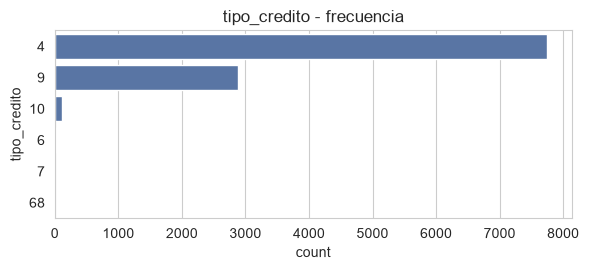

=== tipo_laboral ===
               conteo    pct
tipo_laboral                
Empleado         6754  62.75
Independiente    4009  37.25



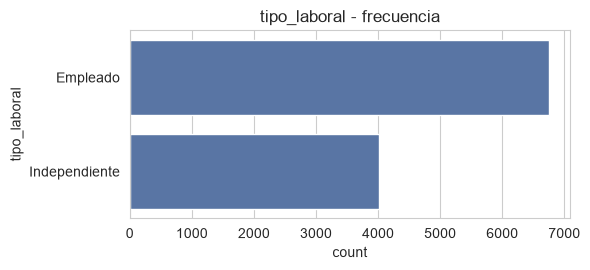

=== tendencia_ingresos ===
                    conteo    pct
tendencia_ingresos               
Creciente             5294  68.11
Decreciente           1291  16.61
Estable               1188  15.28



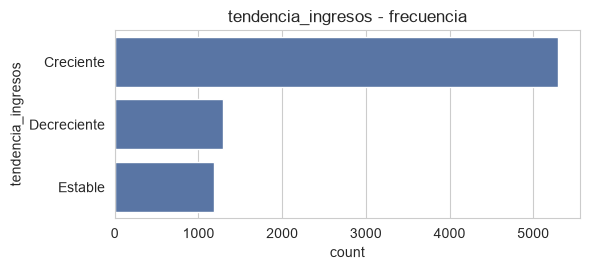

In [27]:
for columna in VARIABLES_CATEGORICAS:
    conteo_abs = df[columna].value_counts(dropna=True)
    conteo_rel = (df[columna].value_counts(normalize=True, dropna=True) * 100).round(2)
    tabla = pd.DataFrame({"conteo": conteo_abs, "pct": conteo_rel})
    print(f"=== {columna} ===")
    print(tabla)

    raras = tabla[tabla["pct"] < 1]
    if not raras.empty:
        print(f"Categorías raras (<1%): {list(raras.index)}")
    print()

    plt.figure(figsize=(6, 2.8))
    sns.countplot(data=df, y=columna, order=conteo_abs.index, color="#4C72B0")
    plt.title(f"{columna} - frecuencia")
    plt.tight_layout()
    plt.show()

**Interpretación.** `tipo_credito` está dominado por los códigos `4` (≈72%) y `9` (≈27%); el resto de los códigos (`10`, `6`, `7`, `68`) suman menos del 1.5% combinados, y `7` y `68` son casos aislados (una y dos filas) — `68` en particular llama la atención por no encajar con el resto de códigos (parecen de un dígito), posible error de captura a revisar, no a borrar todavía. `tipo_laboral` es una dicotómica balanceada razonablemente (mayoría `Empleado`). `tendencia_ingresos` (ya sin los valores fuera de dominio, unificados a NaN en la sección anterior) está dominada por `Creciente`, con `Decreciente` y `Estable` como categorías minoritarias pero no raras.

## Variable objetivo: `Pago_atiempo`

Análisis aparte porque es la variable a predecir: acá el desbalance de clases importa para decidir cómo modelar y qué métrica usar, no para decidir si la columna es "rara".

              conteo    pct
Pago_atiempo               
1              10252  95.25
0                511   4.75


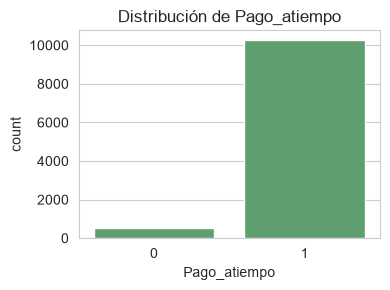

In [28]:
conteo_pago = df["Pago_atiempo"].value_counts()
pct_pago = (df["Pago_atiempo"].value_counts(normalize=True) * 100).round(2)
tabla_pago = pd.DataFrame({"conteo": conteo_pago, "pct": pct_pago})
print(tabla_pago)

plt.figure(figsize=(4, 3))
sns.countplot(data=df, x="Pago_atiempo", color="#55A868")
plt.title("Distribución de Pago_atiempo")
plt.tight_layout()
plt.show()

**Interpretación.** La clase `1` (pagó a tiempo) concentra alrededor del 95% de los créditos, contra apenas ~5% de la clase `0`. Es un desbalance fuerte, no un detalle menor: un modelo que prediga siempre "pagó a tiempo" ya acertaría ~95% de las veces sin aprender nada útil, así que el **accuracy no sirve** como métrica principal. Para modelar esto va a hacer falta mirar precision/recall/F1 de la clase minoritaria (el no-pago, que es la que realmente le importa al negocio), curvas precision-recall (mejor que ROC-AUC con este nivel de desbalance), y probablemente técnicas de manejo de desbalance (`class_weight`, sobremuestreo/submuestreo, o ambos) más una partición estratificada de train/test.

## Tablas pivote

Dos tablas que resumen una numérica agregada por una categórica, con conteo y media, para empezar a ver si el tipo de crédito o la situación laboral se asocian con montos distintos.

In [29]:
pivot_capital_por_tipo_credito = df.pivot_table(
    index="tipo_credito", values="capital_prestado", aggfunc=["count", "mean"]
)
pivot_capital_por_tipo_credito.columns = ["conteo", "capital_prestado_promedio"]
pivot_capital_por_tipo_credito.sort_values("conteo", ascending=False)

,conteo,capital_prestado_promedio
tipo_credito,,
4,7747,2.414644e+06
9,2876,2.445491e+06
10,116,3.292477e+06
6,21,2.860483e+06
7,2,8.117212e+06
68,1,2.822824e+06


In [30]:
pivot_salario_por_tipo_laboral = df.pivot_table(
    index="tipo_laboral", values="salario_cliente", aggfunc=["count", "mean"]
)
pivot_salario_por_tipo_laboral.columns = ["conteo", "salario_promedio"]
pivot_salario_por_tipo_laboral

,conteo,salario_promedio
tipo_laboral,,
Empleado,6754,2.134964e+07
Independiente,4009,1.025317e+07


**Interpretación.** El capital promedio varía según `tipo_credito` (se ve en la tabla pivote), aunque los tipos con muy pocas filas (`7`, `68`) no son representativos y su promedio no debería sobreinterpretarse. En `salario_cliente` por `tipo_laboral`, el promedio de `Empleado` queda inflado por los mismos valores extremos (miles de millones) vistos en la sección de outliers: 36 de los 37 salarios por encima de 500 millones son de clientes `Empleado`, no `Independiente`. Sin esos extremos, los promedios de ambos grupos son mucho más parecidos (~5.2M vs ~4.8M COP) — un motivo más para tratar esos valores antes de sacar conclusiones de negocio sobre esta comparación.